In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
import joblib

In [2]:
df=pd.read_csv("heart.csv")

In [3]:
df = pd.get_dummies(df)

In [4]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [6]:
model=keras.Sequential([
    keras.layers.Dense(units=128,activation='relu',kernel_regularizer=regularizers.l2(0.001),input_shape=(X_train.shape[1],)),
    keras.layers.Dense(units=64,activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dense(units=1,activation='sigmoid')
])

c:\Users\lokit\Coding\Lokit_Projects\Python\Jupyter\.ipynb_checkpoints\Heart Disease Prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [9]:
history=model.fit(X_train,y_train,epochs=50,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7943 - loss: 0.6132 - val_accuracy: 0.8424 - val_loss: 0.5027
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8719 - loss: 0.4501 - val_accuracy: 0.8478 - val_loss: 0.4666
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8760 - loss: 0.4235 - val_accuracy: 0.8587 - val_loss: 0.4442
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8815 - loss: 0.4075 - val_accuracy: 0.8533 - val_loss: 0.4346
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8883 - loss: 0.3943 - val_accuracy: 0.8587 - val_loss: 0.4289
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8842 - loss: 0.3827 - val_accuracy: 0.8696 - val_loss: 0.4198
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8856 - loss: 0.3737 - val_accuracy: 0.8696 - val_loss: 0.4091
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8924 - loss: 0.3647 - val_accuracy: 0.8804 - val_loss:

In [10]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9076 - loss: 0.4408 
Test Loss: 0.44075343012809753
Test Accuracy: 0.907608687877655


In [11]:
predictions=model.predict(X_test)
predictions = (predictions > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [12]:
print("Predicted:")
print(predictions[:10])

print("Actual:")
print(y_test[:10].values)

Predicted:
[[0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]]
Actual:
[0 1 1 1 0 1 1 0 1 1]


In [13]:
cm=confusion_matrix(y_test,predictions)
cm

array([[71,  6],
       [11, 96]])

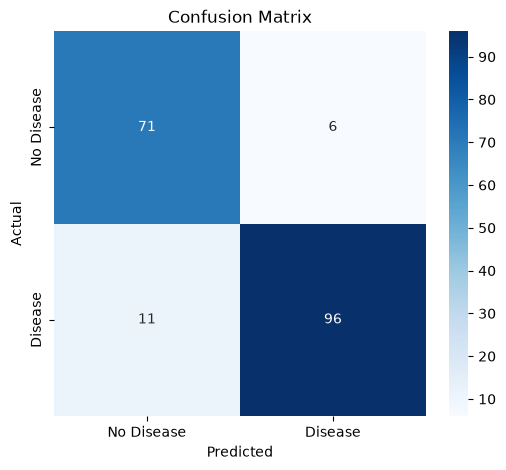

In [14]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.87      0.92      0.89        77
           1       0.94      0.90      0.92       107

    accuracy                           0.91       184
   macro avg       0.90      0.91      0.91       184
weighted avg       0.91      0.91      0.91       184



In [16]:
new_patient = pd.DataFrame({
    'Age': [45],
    'Sex': ['M'],
    'ChestPainType': ['ATA'],
    'RestingBP': [130],
    'Cholesterol': [250],
    'FastingBS': [0],
    'RestingECG': ['Normal'],
    'MaxHR': [170],
    'ExerciseAngina': ['N'],
    'Oldpeak': [0.0],
    'ST_Slope': ['Up']
})

In [17]:
new_patient = pd.get_dummies(new_patient, drop_first=True)

In [18]:
new_patient = new_patient.reindex(columns=X.columns, fill_value=0)

In [19]:
new_patient = scaler.transform(new_patient)

In [20]:
prediction = model.predict(new_patient)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[0.09096018]]


In [21]:
if prediction[0][0] >= 0.5:
    print("Heart Disease")
else:
    print("No Heart Disease")

No Heart Disease


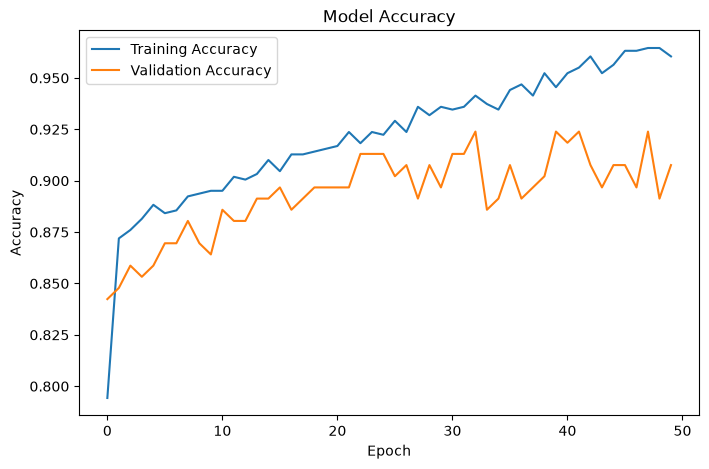

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

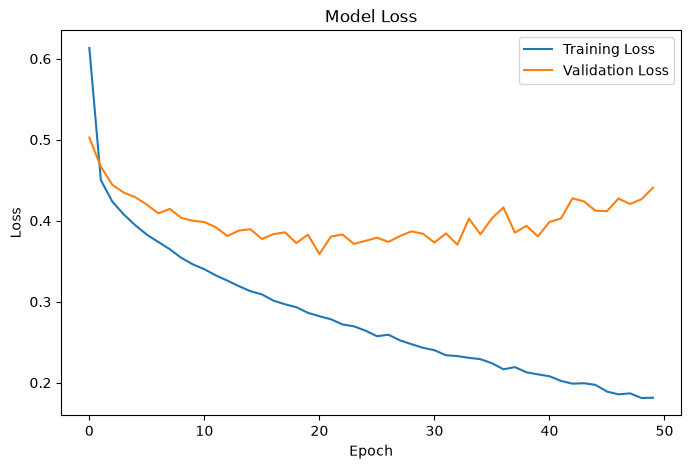

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [24]:
model.save("heart_disease_model.keras")

# from tensorflow import keras
# model = keras.models.load_model("heart_disease_model.keras")

In [25]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [26]:
joblib.dump(X.columns.tolist(),"columns.pkl")

['columns.pkl']